# Generalization_error_learning

In [5]:
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

#### Generating dataset (x_mu, y_mu), mu = 1,...,n


In [6]:
def gen_data(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    F: NDArray[np.floating], # size: dxp,
    theta_0: NDArray[np.floating], # size: dx1,
    sigma,
    f_0,
) -> tuple[NDArray[np.floating], NDArray[np.floating]]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    # drawing C (nxd) with i.i.d. N(0, 1) entries
    C = np.random.normal(0, 1, size=(n, d))

    y = f_0(C @ theta_0)
    X = sigma(C @ F)

    return X, y

In [7]:
d=100
alpha = 0.5
gamma = 0.1
F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
theta_0=np.random.normal(0, 1, size=(d,))

X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))


#### Generalization Errors

In [8]:
def ave_gen_error(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    lamb: float,
    sigma,
    f_0,
    f_hat,
    n_seeds: int,
    k=1,
    loss_fcn: str = "square",
    projection: str = "gaussian"
) -> tuple[float, float, int, int]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    E_g = 0

    for i in range(1, n_seeds+1):
        # draw F, theta_0

        if projection == "gaussian":     
            F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
        elif projection == "orthogonal":
            F = orthogonally_invariant_matrix(d=d, p=math.floor(2*d/alpha)) 
        elif projection == "orthogonal_general":
            F = orthogonally_invariant_matrix_general(d=d, p=math.floor(2*d/alpha))
        elif projection == "orthogonal_projection":
            F = orthogonally_invariant_matrix_powerlaw(d=d, p=math.floor(2*d/alpha))
            

        theta_0=np.random.normal(0, 1, size=(d,))

        X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
 
        ## Square Loss
        if loss_fcn == "square":
            if n>p:
                w_hat = np.linalg.inv((X.T @ X + lamb * np.eye(p))) @ X.T @ y
            else:
                w_hat = X.T @ np.linalg.inv((X@ X.T + lamb * np.eye(n))) @ y
            
            loss = (1/2 * np.linalg.norm(y -  (X @ w_hat))**2 + lamb/2 * np.linalg.norm(w_hat)**2)/n

        ## Logistic Loss
        elif loss_fcn == "logistic":
            clf = LogisticRegression(
                penalty="l2",
                C=1.0 / lamb if lamb > 0 else 1e12,
                fit_intercept=False,
                solver="lbfgs",
                max_iter=1000,
            )
            clf.fit(X, y)
            w_hat = clf.coef_.ravel()
            loss = (np.log(1 + np.exp(-y * (X @ w_hat))).sum() + lamb/2 * np.linalg.norm(w_hat)**2/n)/n
            
        #print(f"Training Loss: {loss}")
        
        X_new, y_new = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
        #???

        
        E_g = E_g + (1/(4**k*n)) * np.linalg.norm(y_new -  f_hat(X_new @ w_hat))**2

    return E_g/n_seeds, loss, p, n

In [9]:
alphas = []

gen_errors_square = []
losses_square = []


for i in range(1,100):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/3
    print(i)
    eps_g_square, loss_square, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=40, loss_fcn="square")
    gen_errors_square.append(eps_g_square)
    losses_square.append(loss_square)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [10]:
alphas = []

gen_errors_logistic = []
losses_logistic = []


for i in range(1,100):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/3
    print(i)
    eps_g_logistic, loss_logistic, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=40, loss_fcn="logistic")
    gen_errors_logistic.append(eps_g_logistic)
    losses_logistic.append(loss_logistic)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


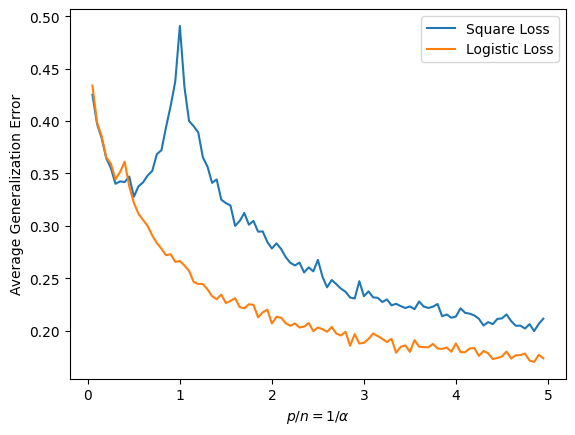

In [11]:
plt.plot([1/alpha for alpha in alphas],gen_errors_square)
plt.plot([1/alpha for alpha in alphas],gen_errors_logistic)
plt.xlabel(r'$p/n =  1/\alpha$')
plt.ylabel('Average Generalization Error')
plt.legend(['Square Loss', 'Logistic Loss'])

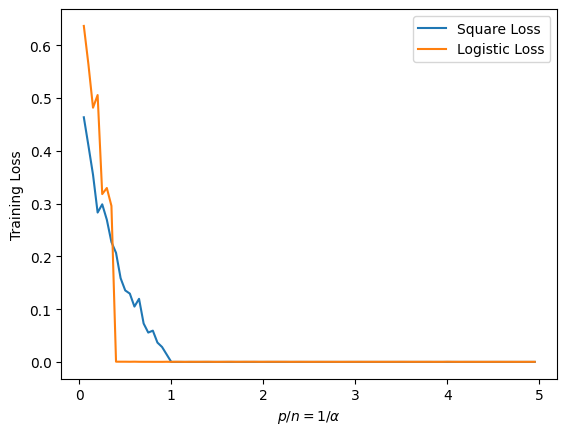

In [12]:
plt.plot([1/alpha for alpha in alphas], losses_square)
plt.plot([1/alpha for alpha in alphas], losses_logistic) 
plt.xlabel(r'$p/n =  1/\alpha$')
plt.ylabel('Training Loss')
plt.legend(['Square Loss', 'Logistic Loss'])

## Generalization error of the logistic loss at fixed very small regularization for random Gaussian features

In [16]:
def ave_gen_error_v2(
    d: int, # hidden manifold dimension
    p: int, # inp. data points number of features
    n: int, # number of samples
    lamb: float,
    sigma,
    f_0,
    f_hat,
    n_seeds: int,
    k=1,
    loss_fcn: str = "square", 
) -> tuple[float, float, int, int]:

    alpha = n/p
    gamma = d/p

    E_g = 0

    for i in range(1, n_seeds+1):
        # draw F, theta_0

        theta_0=np.random.normal(0, 1, size=(d,))
        
        F = np.random.normal(0, 1, size=(d, p)) # Gaussian projections

        X, y = gen_data(d=d, alpha=alpha, gamma=d/p, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
 
        ## Square Loss
        if loss_fcn == "square":
            if n>p:
                w_hat = np.linalg.inv((X.T @ X + lamb * np.eye(p))) @ X.T @ y
            else:
                w_hat = X.T @ np.linalg.inv((X@ X.T + lamb * np.eye(n))) @ y
            
            loss = (1/2 * np.linalg.norm(y -  (X @ w_hat))**2 + lamb/2 * np.linalg.norm(w_hat)**2)/n

        ## Logistic Loss
        elif loss_fcn == "logistic":
            clf = LogisticRegression(
                penalty="l2",
                C=1.0 / lamb if lamb > 0 else 1e12,
                fit_intercept=False,
                solver="lbfgs",
                max_iter=1000,
            )
            clf.fit(X, y)
            w_hat = clf.coef_.ravel()
            loss = (np.log(1 + np.exp(-y * (X @ w_hat))).sum() + lamb/2 * np.linalg.norm(w_hat)**2/n)/n
            
        #print(f"Training Loss: {loss}")
        
        X_new, y_new = gen_data(d=d, alpha=alpha, gamma=d/p, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
        #???

        
        E_g = E_g + (1/(4**k*n)) * np.linalg.norm(y_new -  f_hat(X_new @ w_hat))**2

    return E_g/n_seeds, loss, p, n, alpha, gamma

In [17]:
alphas = []

gen_errors_logistic_3d = []
n_logistic = [i for i in range(10,400,10)]

for n in n_logistic:
    d = 200
    print(f"n = {n}")
    for p_n in [i/50 for i in range(1,100)]:
        p = math.floor(p_n * n)
        if p>0:
            try:
                eps_g_logistic, _, p, n, alpha, gamma = ave_gen_error_v2(d=d, p=p, n=n, lamb=1e-4, sigma=lambda x: np.sign(x), 
                                f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                                n_seeds=10, loss_fcn="logistic")
                gen_errors_logistic_3d.append([eps_g_logistic, alpha, n, p])

                #print(f"p = {p}, n = {n}, alpha = {alpha}, gamma = {gamma}, p/n = {p/n}, n/d = {n/d}, alpha/gamma = {alpha/gamma}, E_g = {eps_g_logistic}")
            except ValueError:
                pass
            

n = 10
n = 20
n = 30
n = 40
n = 50
n = 60
n = 70
n = 80
n = 90
n = 100
n = 110
n = 120
n = 130
n = 140
n = 150
n = 160
n = 170
n = 180
n = 190
n = 200
n = 210
n = 220
n = 230
n = 240
n = 250
n = 260
n = 270
n = 280
n = 290
n = 300
n = 310
n = 320
n = 330
n = 340
n = 350
n = 360
n = 370
n = 380
n = 390


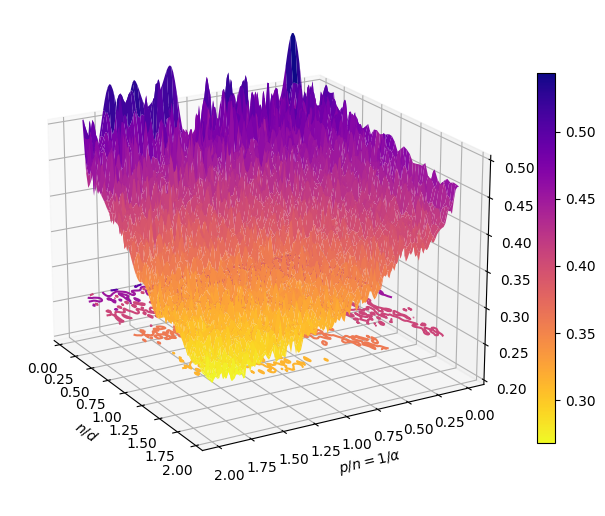

In [18]:
from scipy.interpolate import griddata

gen_errors_logistic_3d = np.array(gen_errors_logistic_3d)

x = gen_errors_logistic_3d[:, 2] / d
y = 1 / gen_errors_logistic_3d[:, 1]
z = gen_errors_logistic_3d[:, 0]

# Fine grid
xi = np.linspace(x.min(), x.max(), 150)
yi = np.linspace(y.min(), y.max(), 150)
X, Y = np.meshgrid(xi, yi)

# Interpolate
Z = griddata((x, y), z, (X, Y), method='cubic')

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z,
    cmap='plasma_r',      # yellow -> violet
    linewidth=0,
    antialiased=True,
    shade=True
)

ax.contour(
    X, Y, Z,
    zdir='z',
    offset=np.nanmin(Z),
    levels=5,
    cmap='plasma_r'
)

ax.invert_yaxis()   # reverse y direction

ax.set_xlabel(r'$n/d$')
ax.set_ylabel(r'$p/n=1/\alpha$')
ax.set_zlabel('Generalisation error')

ax.set_zlim(0.2,0.5)

ax.view_init(elev=20, azim=330)

fig.colorbar(surf, shrink=0.6)
plt.show()

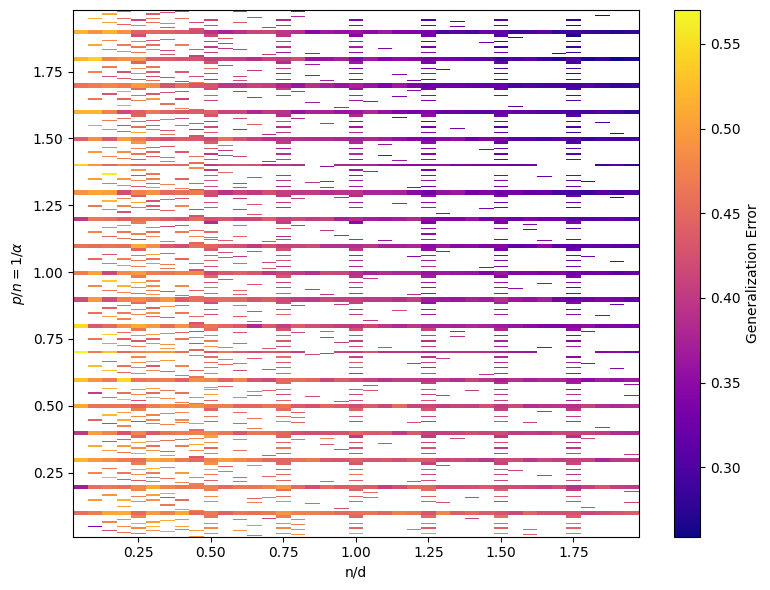

In [19]:
x = gen_errors_logistic_3d[:, 2] / d      # n/d
y = 1 / gen_errors_logistic_3d[:, 1]      # 1/alpha
z = gen_errors_logistic_3d[:, 0]          # generalization error

# Create grid
x_vals = np.sort(np.unique(x))
y_vals = np.sort(np.unique(y))

X, Y = np.meshgrid(x_vals, y_vals)
Z = np.full_like(X, np.nan, dtype=float)

for xi, yi, zi in zip(x, y, z):
    ix = np.where(x_vals == xi)[0][0]
    iy = np.where(y_vals == yi)[0][0]
    Z[iy, ix] = zi

# 2D heatmap
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.pcolormesh(
    X, Y, Z,
    shading='auto',
    cmap='plasma'
)

ax.set_xlabel('n/d')
ax.set_ylabel(r'$p/n=1/\alpha$')

cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label('Generalization Error')

plt.tight_layout()
plt.show()

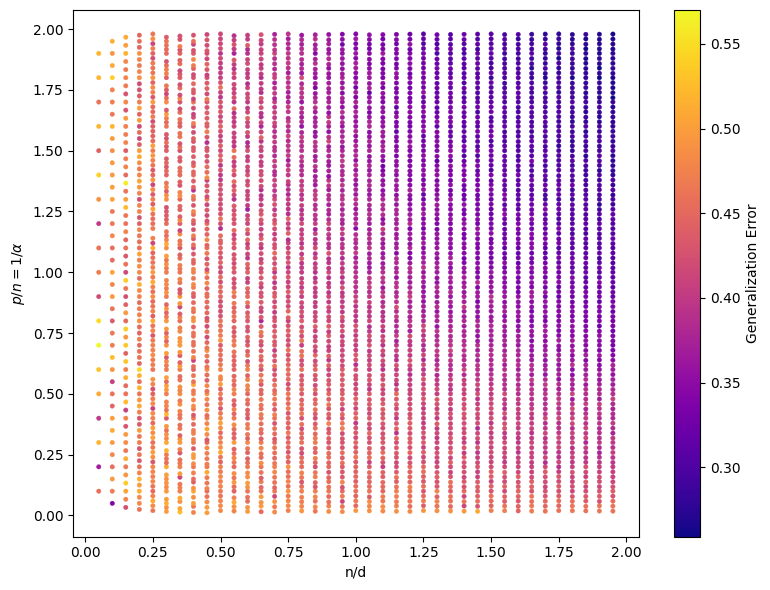

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    X,
    Y,
    c=Z,
    cmap='plasma',
    s=10,          # marker size
    #edgecolors='k',
    linewidths=0.3
)

ax.set_xlabel('n/d')
ax.set_ylabel(r'$p/n = 1/\alpha$')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Generalization Error')

plt.tight_layout()
plt.show()

## Orthogonal Features

In [21]:
def haar_orthogonal(n):
    """
    Haar-distributed orthogonal matrix via QR decomposition.
    """
    Q, R = np.linalg.qr(np.random.randn(n, n))

    # Haar correction
    signs = np.sign(np.diag(R))
    Q *= signs

    return Q

def orthogonally_invariant_matrix(d, p):
    # Haar orthogonal factors
    U = haar_orthogonal(d)
    V = haar_orthogonal(p)

    D = np.zeros((d, p))    
    r = min(d, p)

    D[np.arange(r), np.arange(r)] = max(np.sqrt(p/d), 1.0)

    return U @ D @ V

def orthogonally_invariant_matrix_general(d, p):
    # Haar orthogonal factors
    U = haar_orthogonal(d)
    V = haar_orthogonal(p)

    D = np.zeros((d, p))    
    r = min(d, p)
    s = max(np.sqrt(p / d), 1.0)

    D[np.arange(r), np.arange(r)] = s * np.exp(0.5 * np.random.randn(r))

    return U @ D @ V


def orthogonally_invariant_matrix_powerlaw(d, p):
    # Haar orthogonal factors
    U = haar_orthogonal(d)
    V = haar_orthogonal(p)

    D = np.zeros((d, p))    
    r = min(d, p)
    
    beta = 1
    # power-law 
    singular_values = np.array([i**(-beta) for i in np.arange(1, r + 1).astype(float) ])

    # normalize to match Gaussian scaling
    singular_values *= np.sqrt(
        max(p / d, 1.0) / np.mean(singular_values**2)
    )

    D[np.arange(r), np.arange(r)] = singular_values

    return D





In [22]:
alphas = []

gen_errors_orthogonal = []
gen_errors_gaussian = []

for i in range(1,60):
    alpha = 1/i*20
    alphas.append(alpha)

    d=256
    gamma = alpha/2
    print(i)
    eps_g_gaussian, loss_gaussian, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=40, loss_fcn="logistic", projection="gaussian")
    gen_errors_gaussian.append(eps_g_gaussian)

    eps_g_orthogonal, loss_orthogonal, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=40, loss_fcn="logistic", projection="orthogonal")
    gen_errors_orthogonal.append(eps_g_orthogonal)



1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


Text(0.5, 1.0, 'Logistic Classification - d=256, lambda = 1e-4')

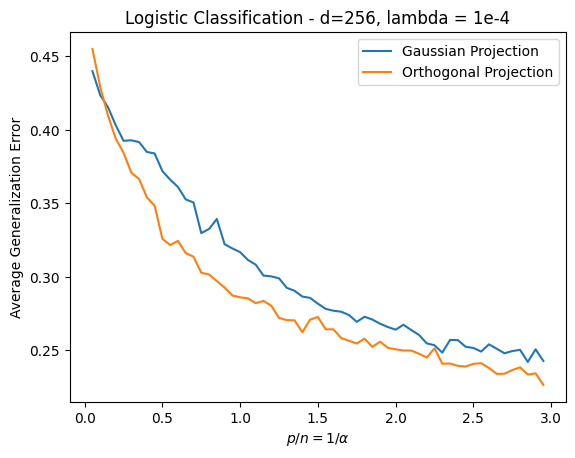

In [23]:
plt.plot([1/alpha for alpha in alphas],gen_errors_gaussian)
plt.plot([1/alpha for alpha in alphas],gen_errors_orthogonal)

plt.xlabel(r'$p/n =  1/\alpha$')
plt.ylabel('Average Generalization Error')
plt.legend(['Gaussian Projection', 'Orthogonal Projection'])
plt.title("Logistic Classification - d=256, lambda = 1e-4")
#plt.ylim(0,20.0)

In [14]:
alphas = []

gen_errors_gaussian_regression = []
gen_errors_orthogonal_regression = []
gen_errors_orthogonal_regression_general = []
gen_errors_orthogonal_regression_powerlaw = []

for i in range(1,60):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/2
    print(i)
    eps_g_gaussian_regression, loss_gaussian_regression, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-8, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: (x), f_hat=lambda x: (x), 
                      n_seeds=40, loss_fcn="square", projection="gaussian", k=0)
    gen_errors_gaussian_regression.append(eps_g_gaussian_regression)

    eps_g_orthogonal_regression, loss_orthogonal_regression, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-8, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: (x), f_hat=lambda x: (x), 
                      n_seeds=40, loss_fcn="square", projection="orthogonal", k=0)
    gen_errors_orthogonal_regression.append(eps_g_orthogonal_regression)
    
    eps_g_orthogonal_regression_general, loss_orthogonal_regression_general, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-8, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: (x), f_hat=lambda x: (x), 
                      n_seeds=40, loss_fcn="square", projection="orthogonal_general", k=0)
    gen_errors_orthogonal_regression_general.append(eps_g_orthogonal_regression_general)

    eps_g_orthogonal_regression_powerlaw, loss_orthogonal_regression_powerlaw, _, _ = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-8, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: (x), f_hat=lambda x: (x), 
                      n_seeds=40, loss_fcn="square", projection="orthogonal_projection", k=0)
    gen_errors_orthogonal_regression_powerlaw.append(eps_g_orthogonal_regression_powerlaw)



1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


(0.0, 2.0)

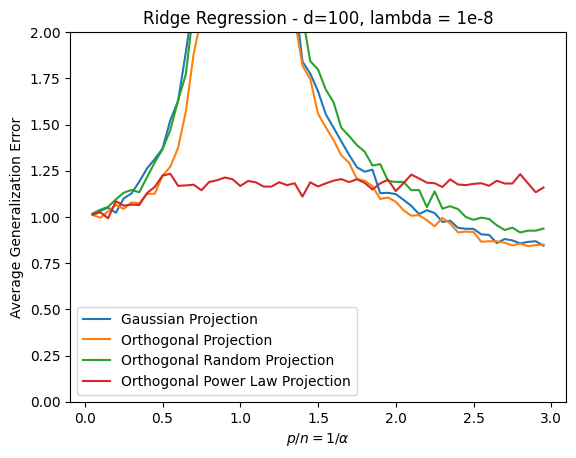

In [24]:
plt.plot([1/alpha for alpha in alphas],gen_errors_gaussian_regression)
plt.plot([1/alpha for alpha in alphas],gen_errors_orthogonal_regression)
plt.plot([1/alpha for alpha in alphas],gen_errors_orthogonal_regression_general)
plt.plot([1/alpha for alpha in alphas],gen_errors_orthogonal_regression_powerlaw)

plt.xlabel(r'$p/n =  1/\alpha$')
plt.ylabel('Average Generalization Error')
plt.legend(['Gaussian Projection', 'Orthogonal Projection', 'Orthogonal Random Projection', 'Orthogonal Power Law Projection'])
plt.title("Ridge Regression - d=100, lambda = 1e-8")
plt.ylim(0,2.0)